# Baseline models: XGB and local-trend-predictor

I've mainly been working on Influenza, though norovirus is supposed to also be an interesting one for this task.

In [2]:
!hpc-ticket
!hpc-mount wissdaten

In [3]:
import importlib.util
import sys
from datetime import date
import pandas as pd
import numpy as np
from typing import Dict, Literal, Optional
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.dates as mdates
import os
from pathlib import Path
from src.dataloading import EpiDataLoader

wissdaten_dir    = os.environ.get('TMPDIR') +'/wissdaten/'
data_env         = os.path.join(wissdaten_dir, 'ZKI-PH4/deschrijvers_wissdaten/data')

data_module      = module_path = data_env + "/__init__.py"
spec = importlib.util.spec_from_file_location("data", module_path)
module = importlib.util.module_from_spec(spec)
sys.modules["data"] = module
spec.loader.exec_module(module)

from data.visuals import *
colors_dict = {}
colors_dict['context']    = hexcodes['sky blue']
colors_dict['future']     = hexcodes['soft red']
colors_dict['predictions']= hexcodes['moss green']

(<Figure size 2200x600 with 3 Axes>, <Axes: >)

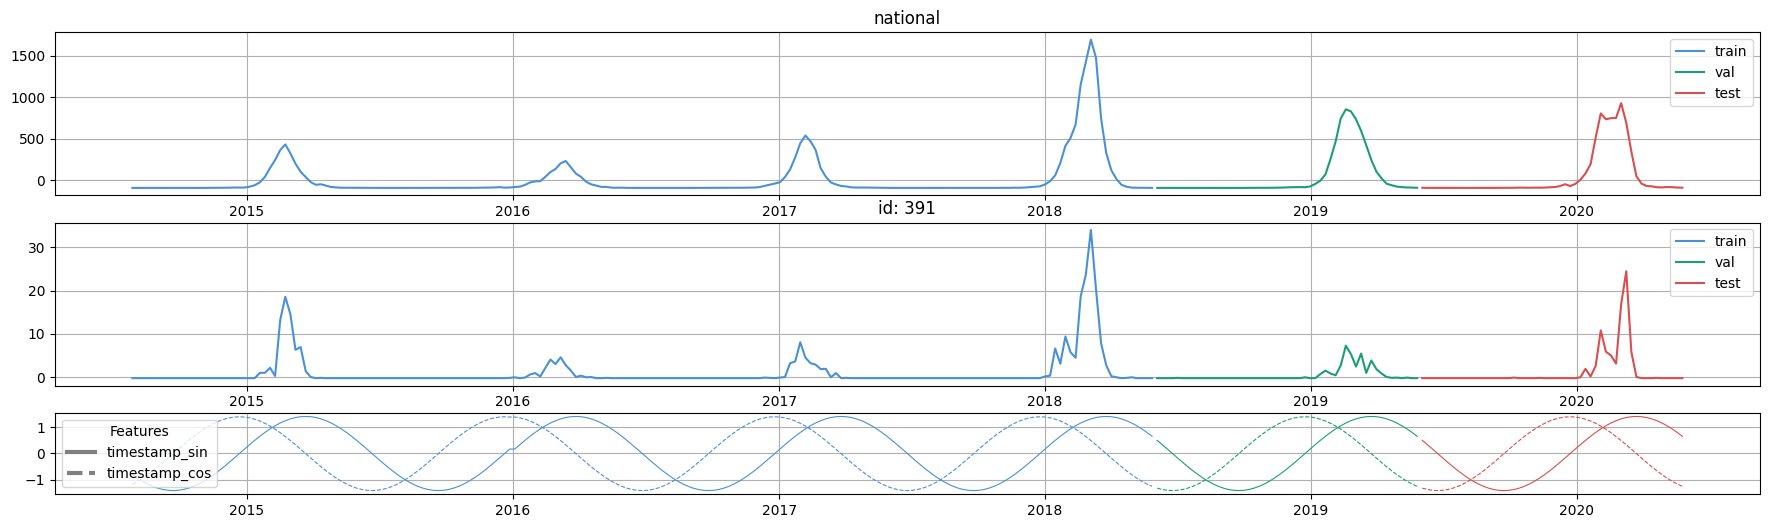

In [7]:
epidata = EpiDataLoader(disease_name = 'influenza', min_date = ' 2014-06-01', data_env_dir = data_env)
epidata.add_time_features()
epidata.normalize('2018-06-01','2019-06-01', method = 'zscore')
epidata.add_lagged_features(lags = range(1,9))
epidata.split_data()
epidata.preview()

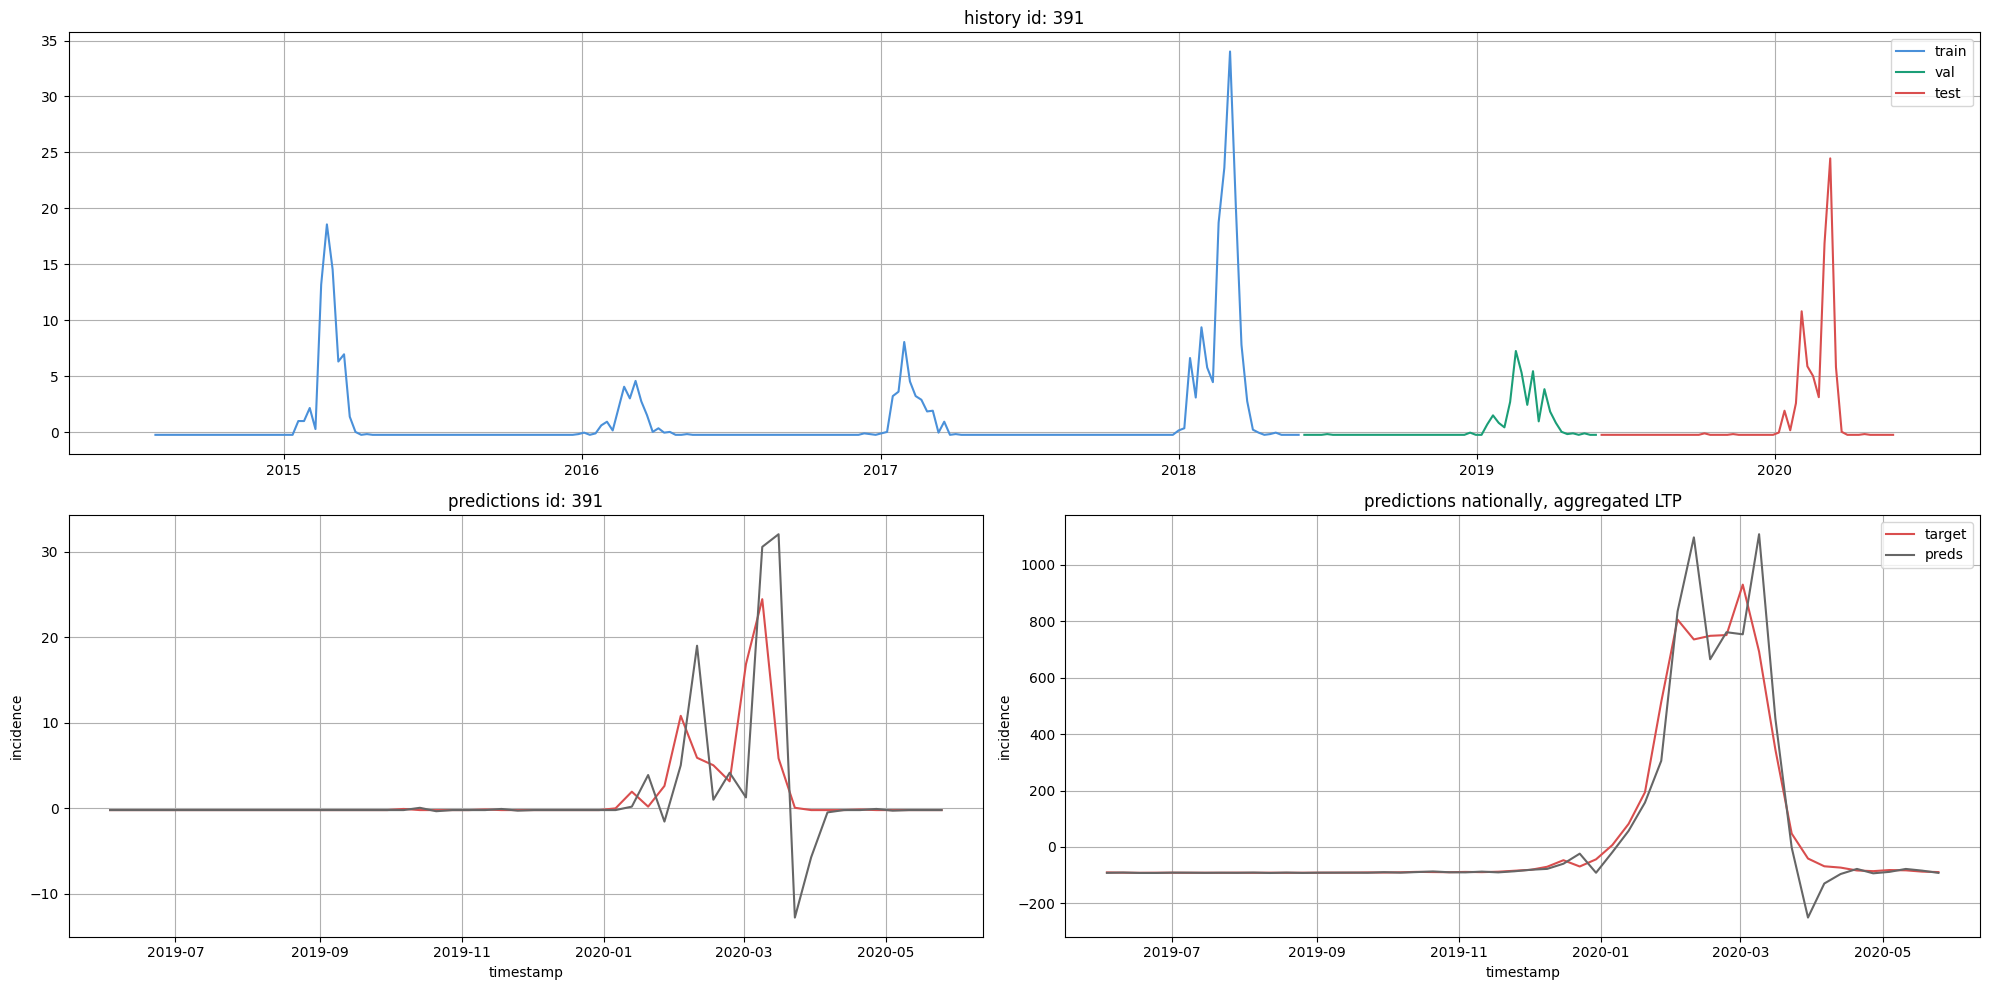

In [8]:
from src.models.localtrendpredictor import LocalTrendPredictor

dataloader_copy = epidata.copy()

ltp = LocalTrendPredictor(dataloader_copy)
ltp.forecast()
ltp.show_forecasts(391)

/home/de-schrijvers/.conda/envs/gnenv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


[0]	train-rmse:0.98262	val-rmse:0.86977
[20]	train-rmse:0.53727	val-rmse:0.46591
[40]	train-rmse:0.39758	val-rmse:0.39090
[60]	train-rmse:0.35119	val-rmse:0.38764
[78]	train-rmse:0.33273	val-rmse:0.39287


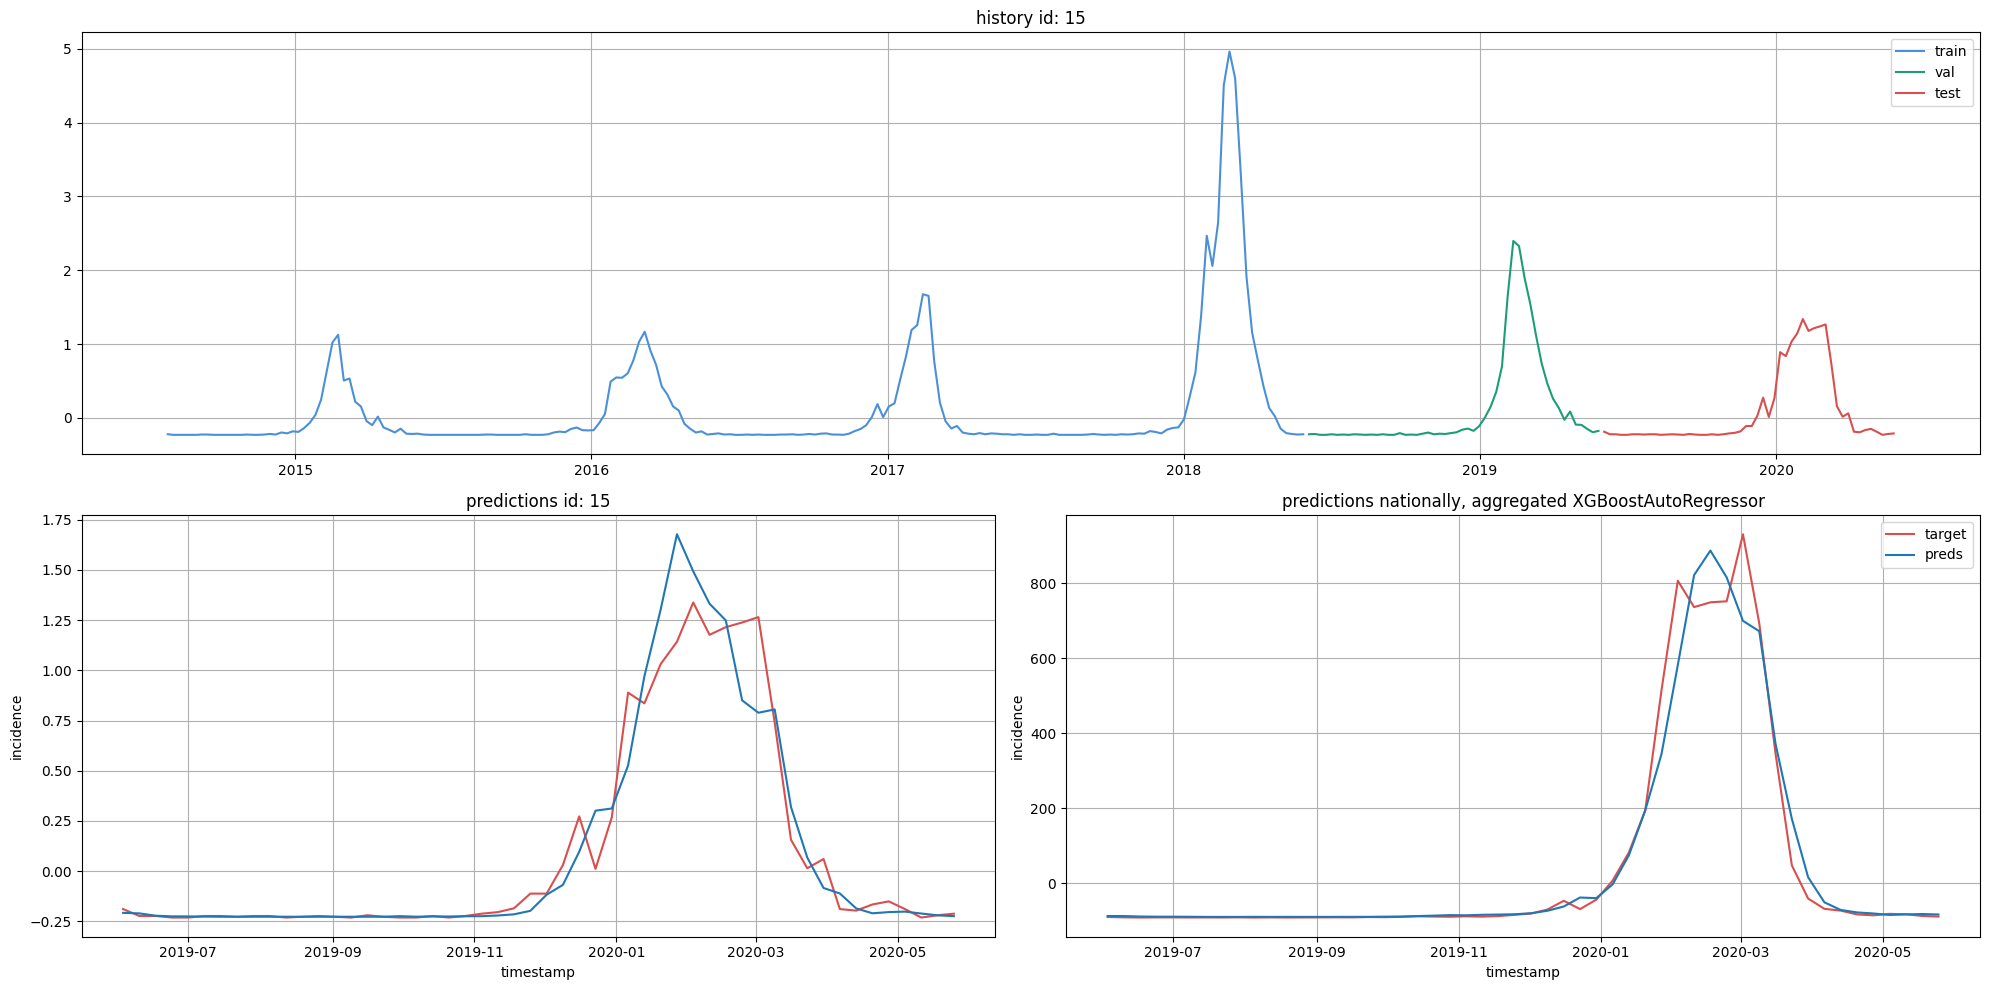

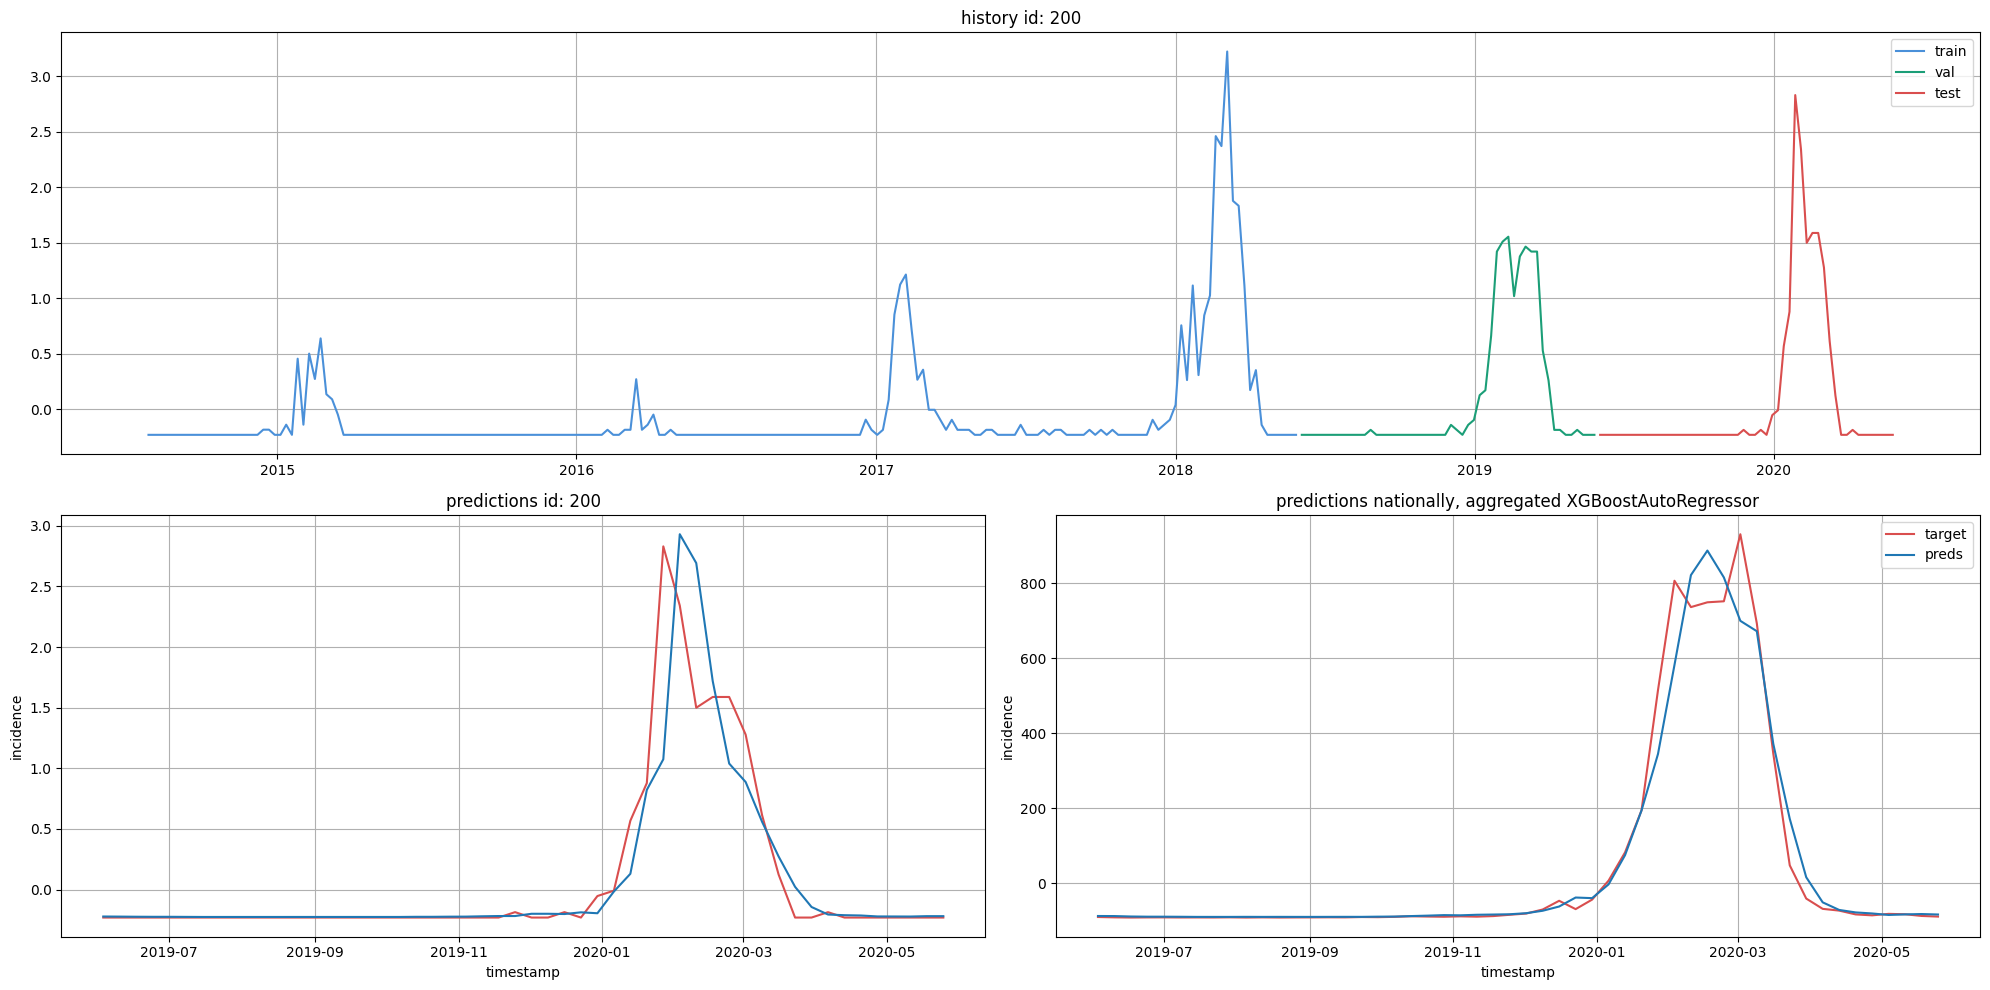

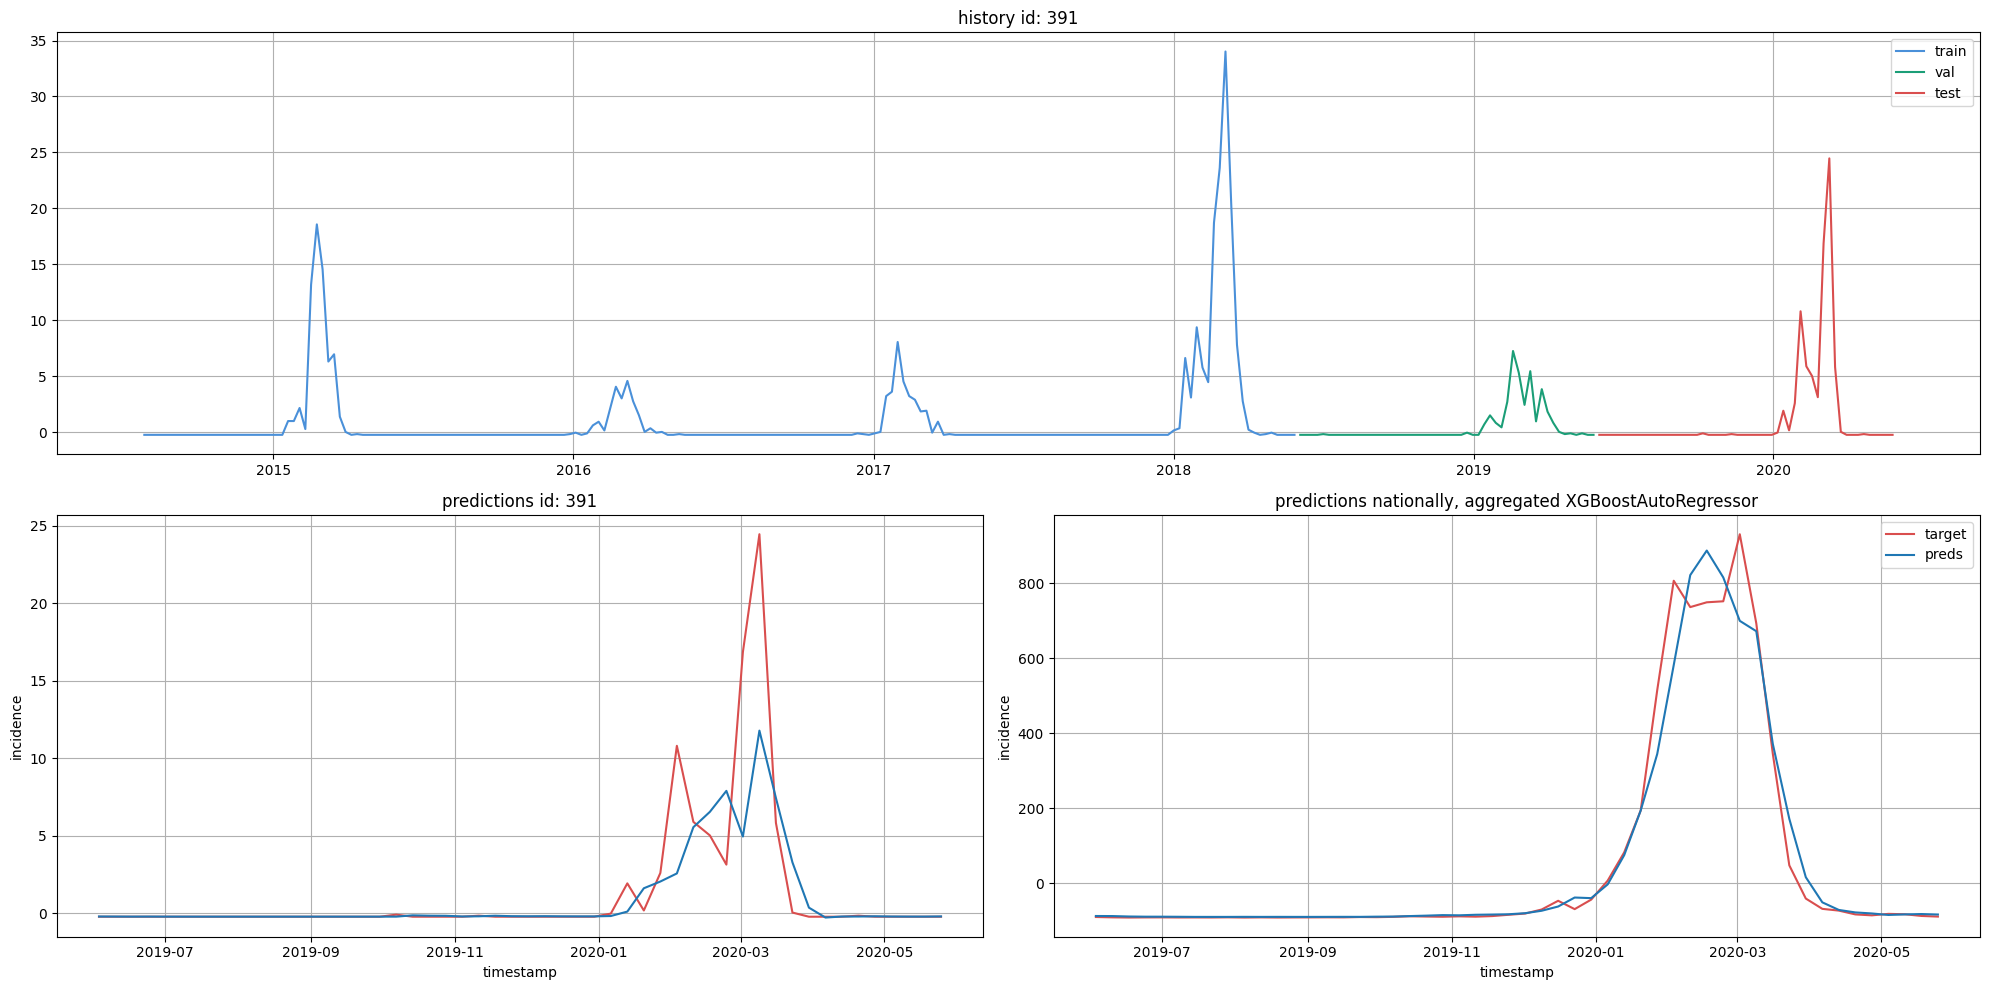

In [9]:
from src.models import XGBoostAutoRegressor
from src.dataloading.epidataloader import EpiDataLoader
from src.dataloading.gnndataloader import GNNDataLoader

xgb_model = XGBoostAutoRegressor(epidata)
xgb_model.forecast()
xgb_model.show_forecasts(15)
xgb_model.show_forecasts(200)
xgb_model.show_forecasts(391)

[0]	train-rmse:0.99367	val-rmse:0.87703
[20]	train-rmse:0.73108	val-rmse:0.59902
[40]	train-rmse:0.65108	val-rmse:0.55268
[60]	train-rmse:0.61560	val-rmse:0.55540
[66]	train-rmse:0.60780	val-rmse:0.55572


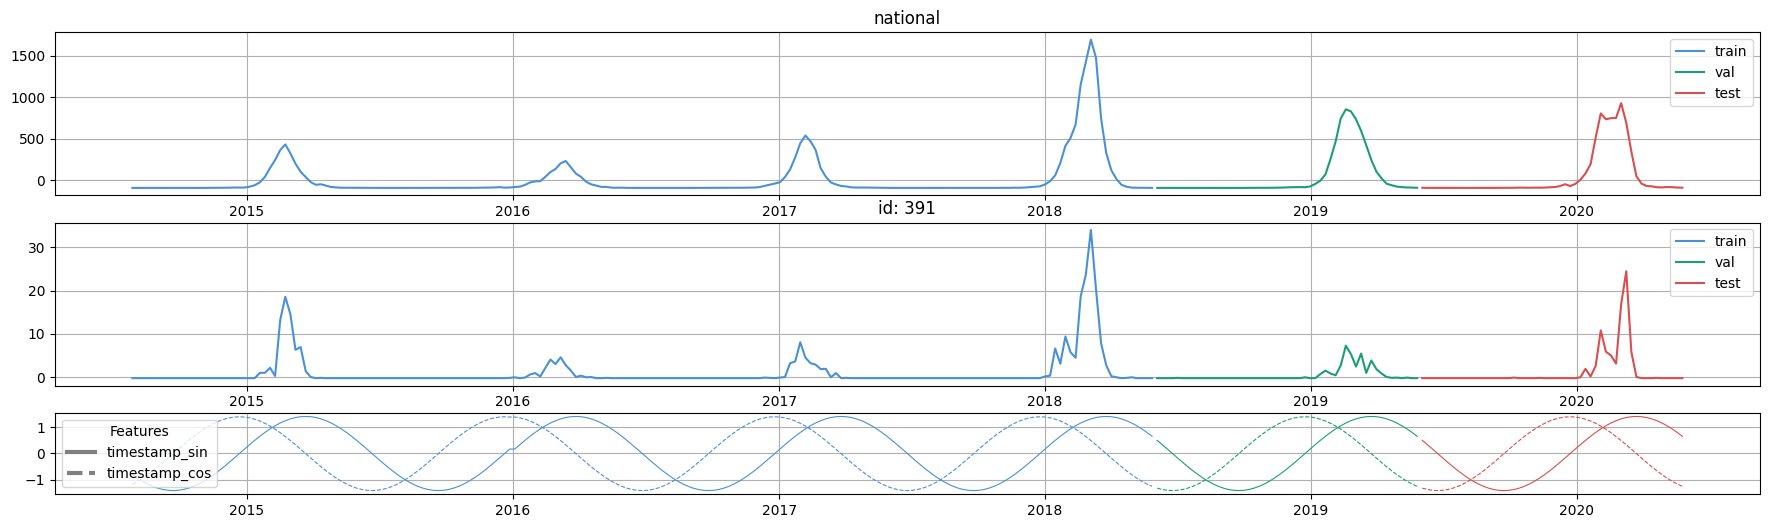

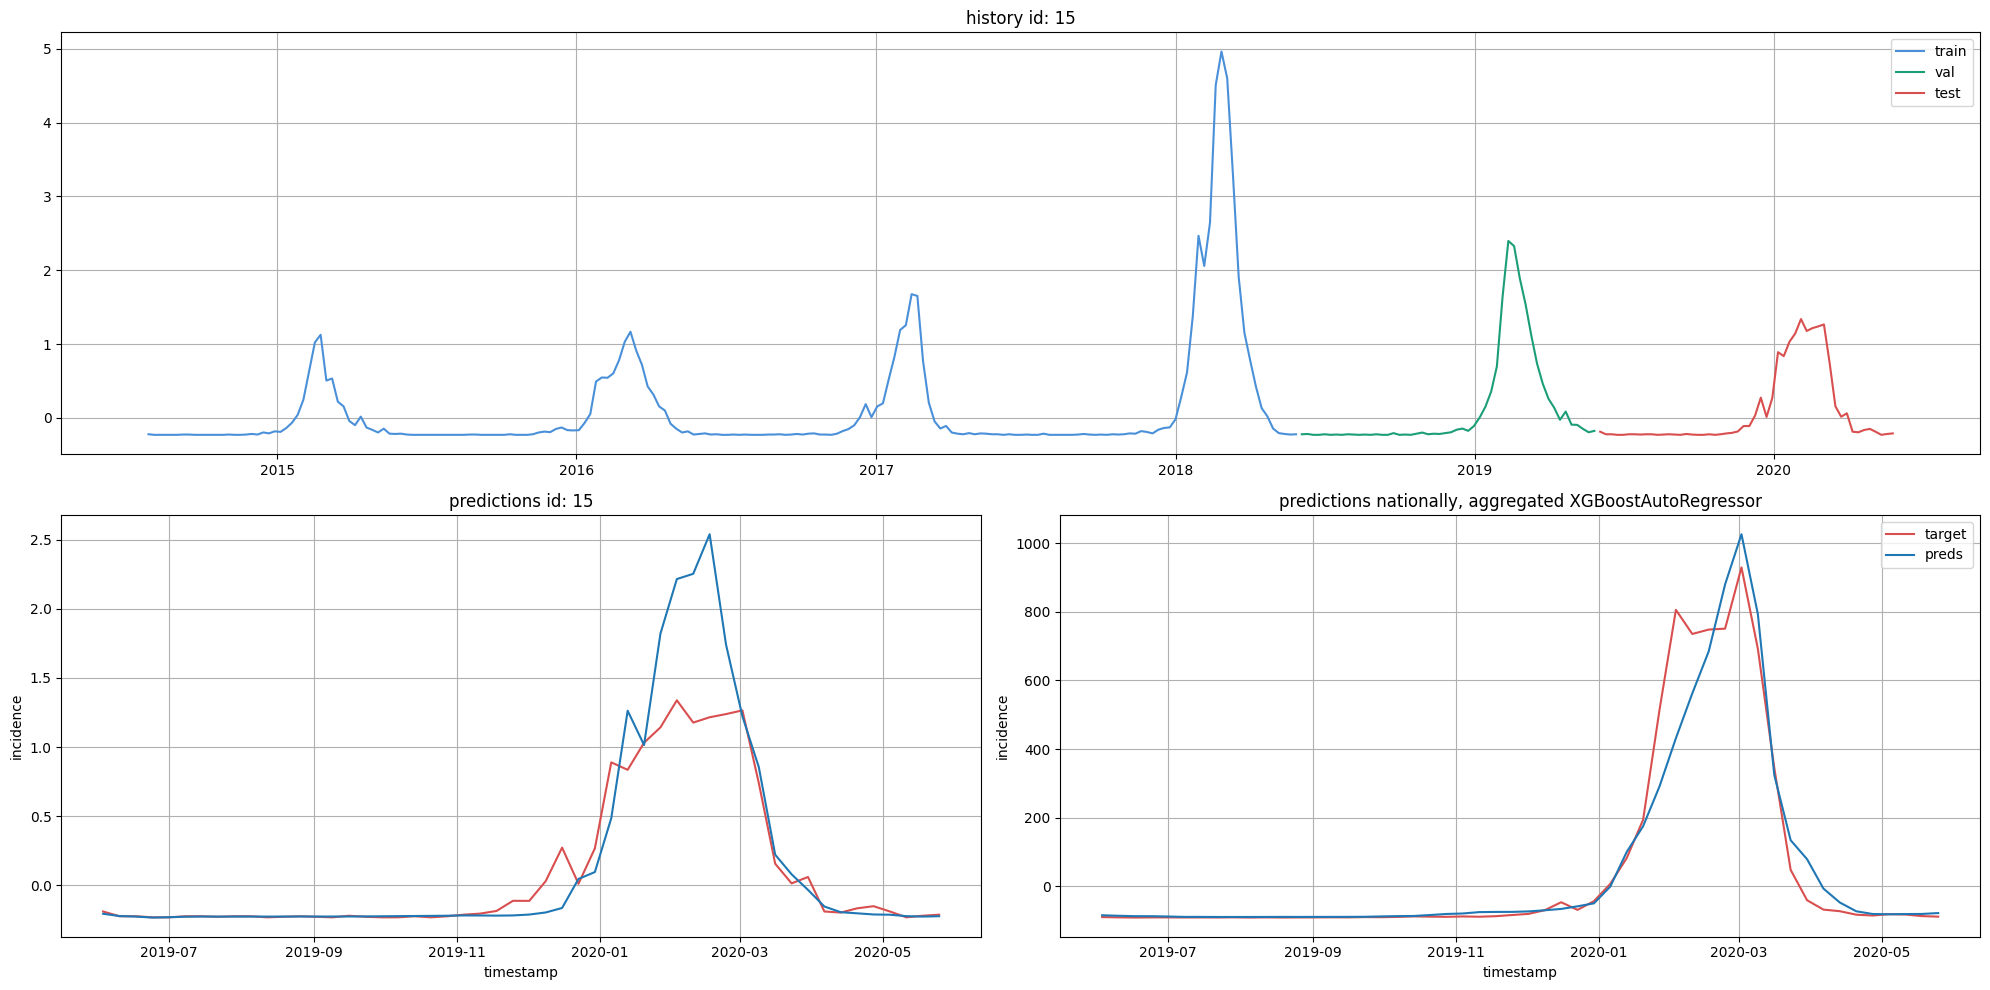

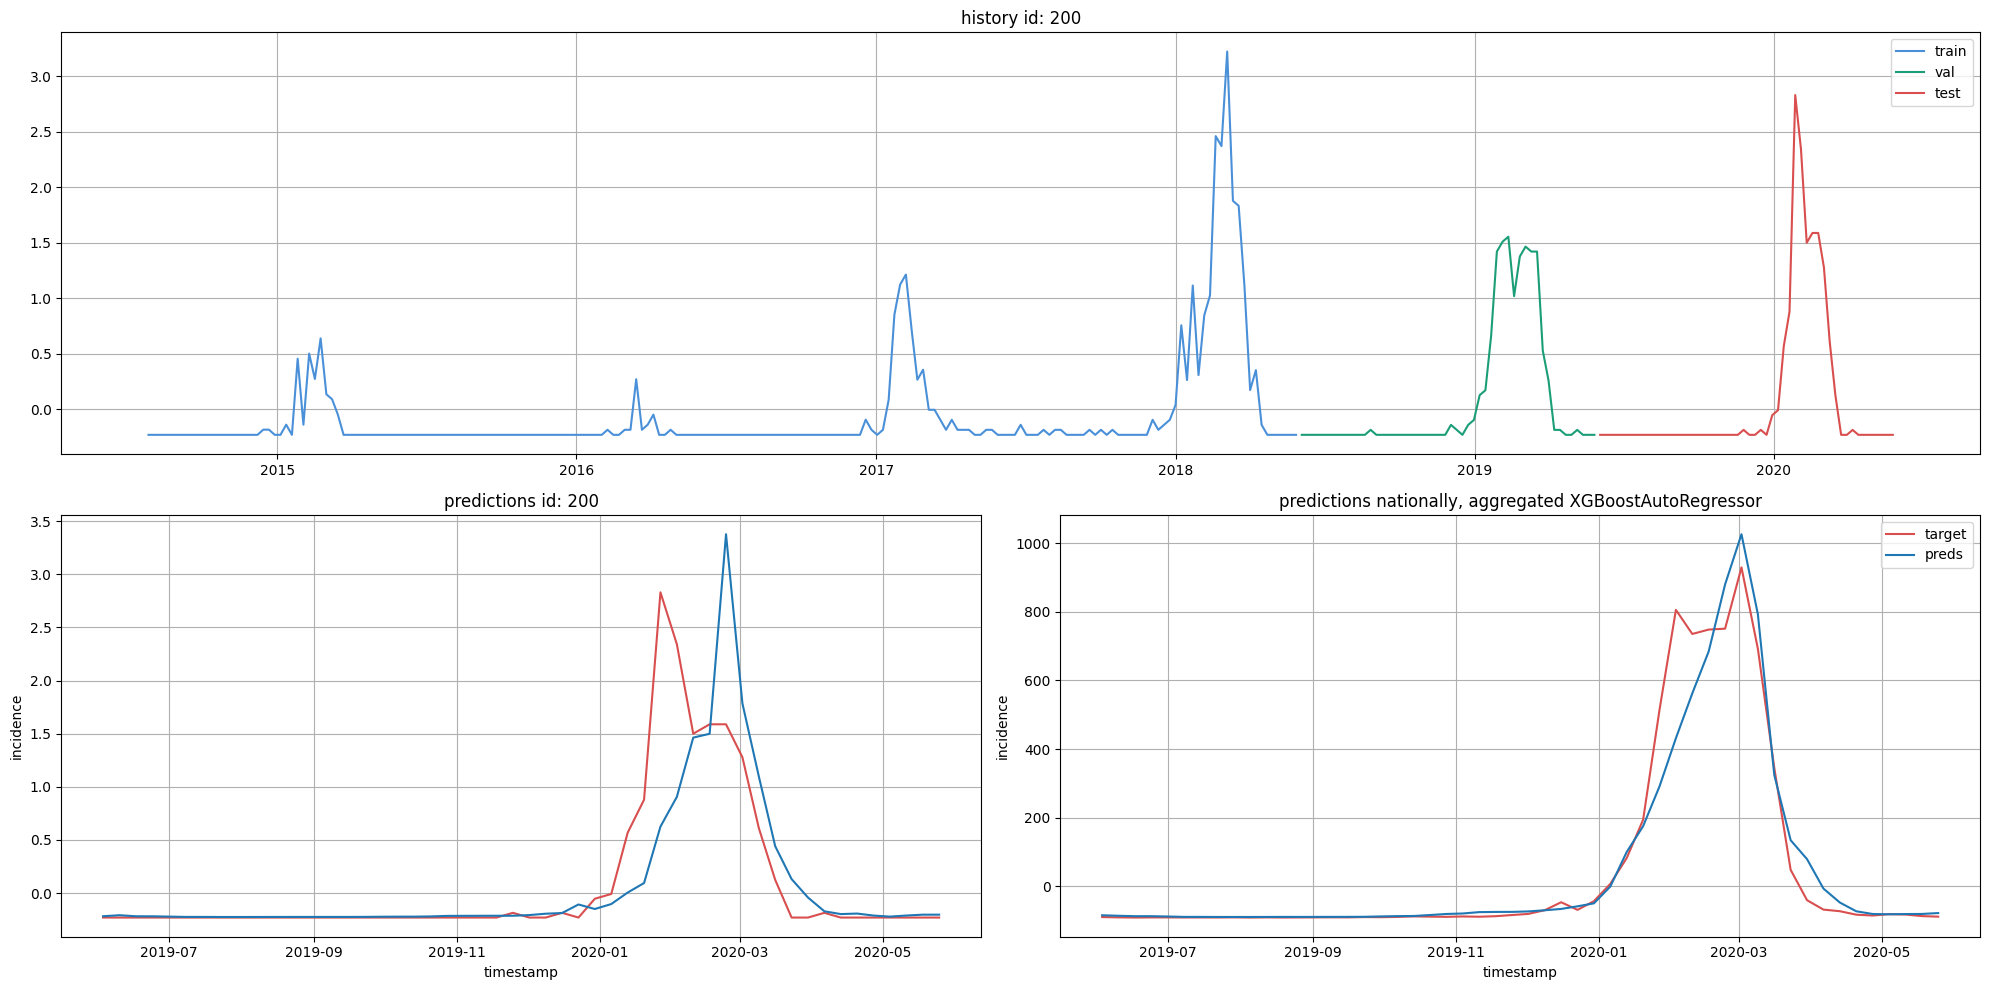

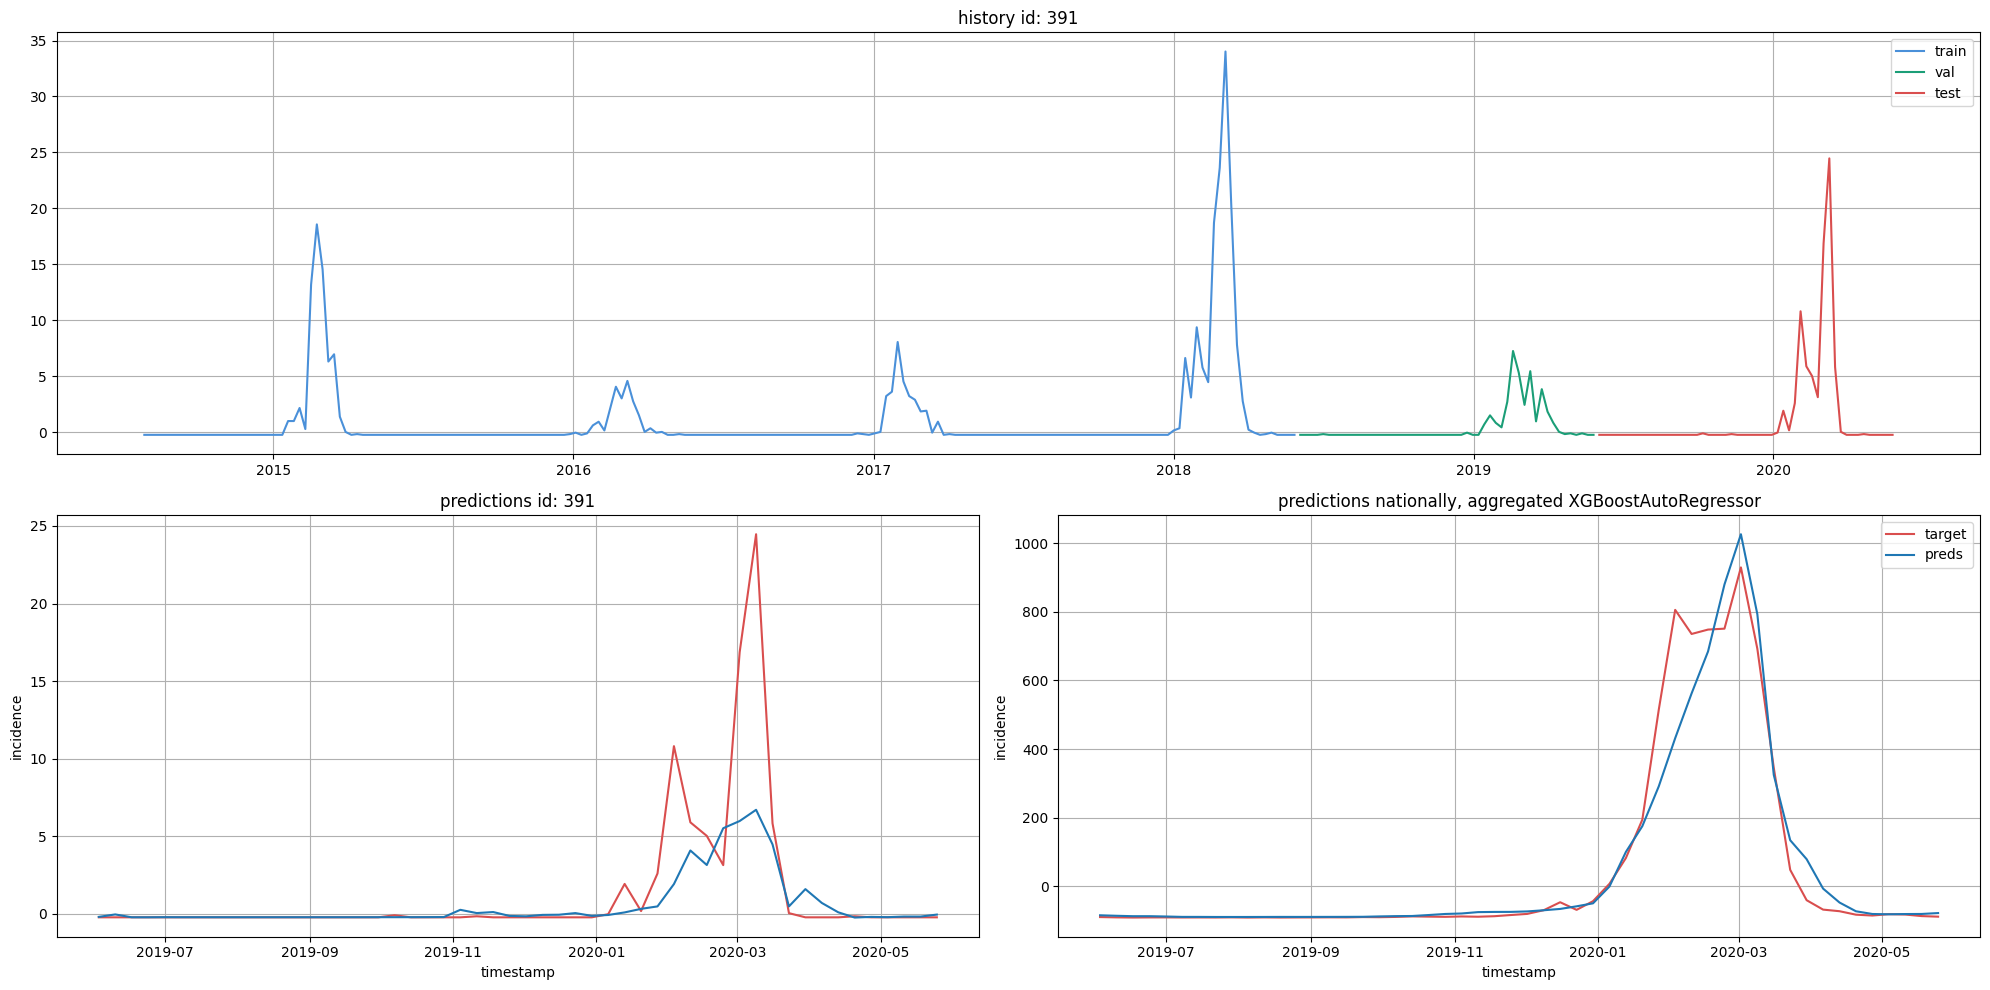

In [10]:
epidata_higher_lag = EpiDataLoader(disease_name = 'influenza', min_date = ' 2014-06-01', data_env_dir = data_env)
epidata_higher_lag.add_time_features()
epidata_higher_lag.normalize('2018-06-01','2019-06-01', method = 'zscore')
epidata_higher_lag.add_lagged_features(lags = range(4,9))
epidata_higher_lag.split_data()
epidata_higher_lag.preview()

xgb_model = XGBoostAutoRegressor(epidata_higher_lag)
xgb_model.forecast()
xgb_model.show_forecasts(15)
xgb_model.show_forecasts(200)
xgb_model.show_forecasts(391)